<a href="https://colab.research.google.com/github/Lemela2189/CCS8---SoftwareEngr/blob/main/CC19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

try:
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv
    !ls -l
    df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'heart_failure_clinical_records_dataset.csv' not found.")
except pd.errors.ParserError:
    print("Error: Unable to parse the CSV file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--2025-04-08 14:57:56--  https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘heart_failure_clinical_records_dataset.csv.2’

heart_failure_clini     [ <=>                ]  11.95K  --.-KB/s    in 0s      

2025-04-08 14:57:57 (101 MB/s) - ‘heart_failure_clinical_records_dataset.csv.2’ saved [12239]

total 40
-rw-r--r-- 1 root root 12239 Apr  8 14:53 heart_failure_clinical_records_dataset.csv
-rw-r--r-- 1 root root 12239 Apr  8 14:54 heart_failure_clinical_records_dataset.csv.1
-rw-r--r-- 1 root root 12239 Apr  8 14:57 heart_failure_clinical_records_dataset.csv.2
drwxr-xr-x 1 root root  4096 Apr  4 13:38 sample_data


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
# Examine the shape of the DataFrame.
print("Shape of the DataFrame:", df.shape)

# Check data types of each column.
print("\nData Types:\n", df.dtypes)

# Identify missing values.
print("\nMissing Values:\n", df.isnull().sum())

# Analyze the distribution of key numerical variables.
print("\nDescriptive Statistics for Numerical Variables:\n", df[['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']].describe())

# Investigate the distribution of categorical variables.
for col in ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']:
    print(f"\nDistribution of {col}:\n{df[col].value_counts(normalize=True)}")

# Briefly consider potential relationships between features and DEATH_EVENT.
print("\nDescriptive Statistics for Numerical Variables grouped by DEATH_EVENT:\n", df.groupby('DEATH_EVENT')[['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']].describe())

Shape of the DataFrame: (299, 13)

Data Types:
 age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Descriptive Statistics for Numerical Variables:


In [ ]:
import pandas as pd
import scipy.stats as stats
from scipy.stats import chi2_contingency

# Calculate the correlation matrix for numerical features
numerical_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
correlation_matrix = df[numerical_features + ['DEATH_EVENT']].corr()
print("Correlation Matrix:\n", correlation_matrix)

# Group data by DEATH_EVENT and calculate descriptive statistics
grouped_data = df.groupby('DEATH_EVENT')[numerical_features].agg(['mean', 'median', 'std'])
print("\nGrouped Descriptive Statistics:\n", grouped_data)

# Perform t-tests or Mann-Whitney U tests
for col in numerical_features:
    group1 = df[df['DEATH_EVENT'] == 0][col]
    group2 = df[df['DEATH_EVENT'] == 1][col]
    if len(group1) < 30 or len(group2) < 30:
        t_stat, p_val = stats.mannwhitneyu(group1, group2)
        print(f"\nMann-Whitney U test for {col}: p-value = {p_val}")
    else:
        t_stat, p_val = stats.ttest_ind(group1, group2)
        print(f"\nT-test for {col}: p-value = {p_val}")

# Perform Chi-squared tests for categorical features
categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['DEATH_EVENT'])
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    print(f"\nChi-squared test for {col}: p-value = {p_val}")

Correlation Matrix:
                                age  creatinine_phosphokinase  \
age                       1.000000                 -0.081584   
creatinine_phosphokinase -0.081584                  1.000000   
ejection_fraction         0.060098                 -0.044080   
platelets                -0.052354                  0.024463   
serum_creatinine          0.159187                 -0.016408   
serum_sodium             -0.045966                  0.059550   
time                     -0.224068                 -0.009346   
DEATH_EVENT               0.253729                  0.062728   

                          ejection_fraction  platelets  serum_creatinine  \
age                                0.060098  -0.052354          0.159187   
creatinine_phosphokinase          -0.044080   0.024463         -0.016408   
ejection_fraction                  1.000000   0.072177         -0.011302   
platelets                          0.072177   1.000000         -0.041198   
serum_creatinine      

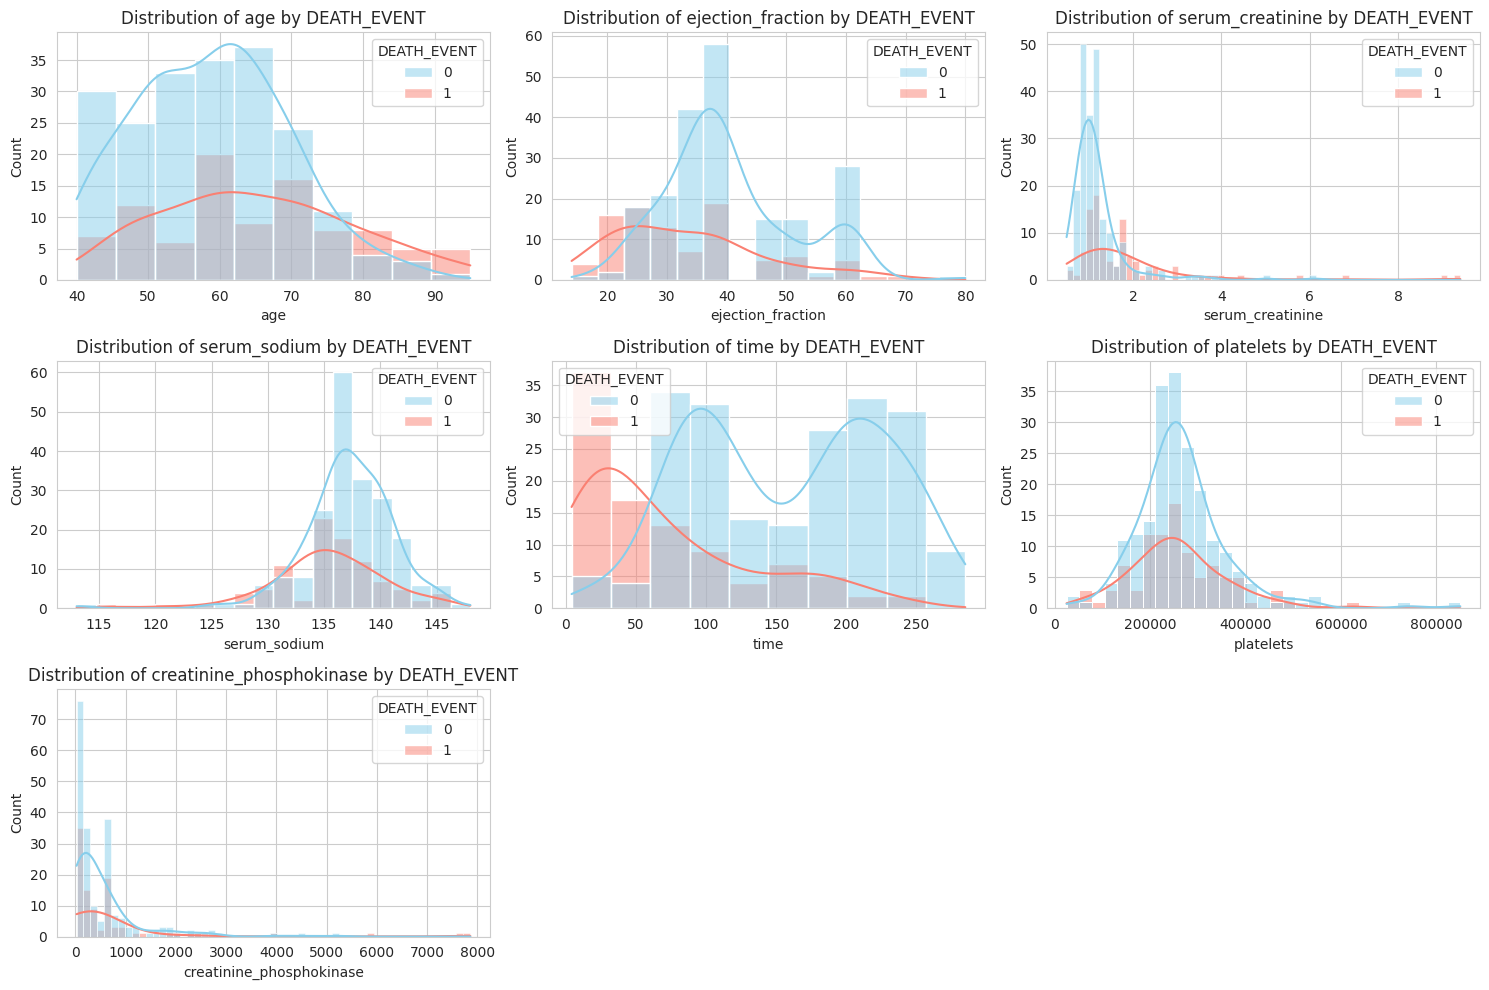

<ipython-input-11-1ba1e1862500>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y=feature, data=df, palette=['skyblue', 'salmon'])
<ipython-input-11-1ba1e1862500>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y=feature, data=df, palette=['skyblue', 'salmon'])
<ipython-input-11-1ba1e1862500>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y=feature, data=df, palette=['skyblue', 'salmon'])
<ipython-input-11-1ba1e1862500>:25: FutureWarning: 

Passing `palette` without assigning `hue` is

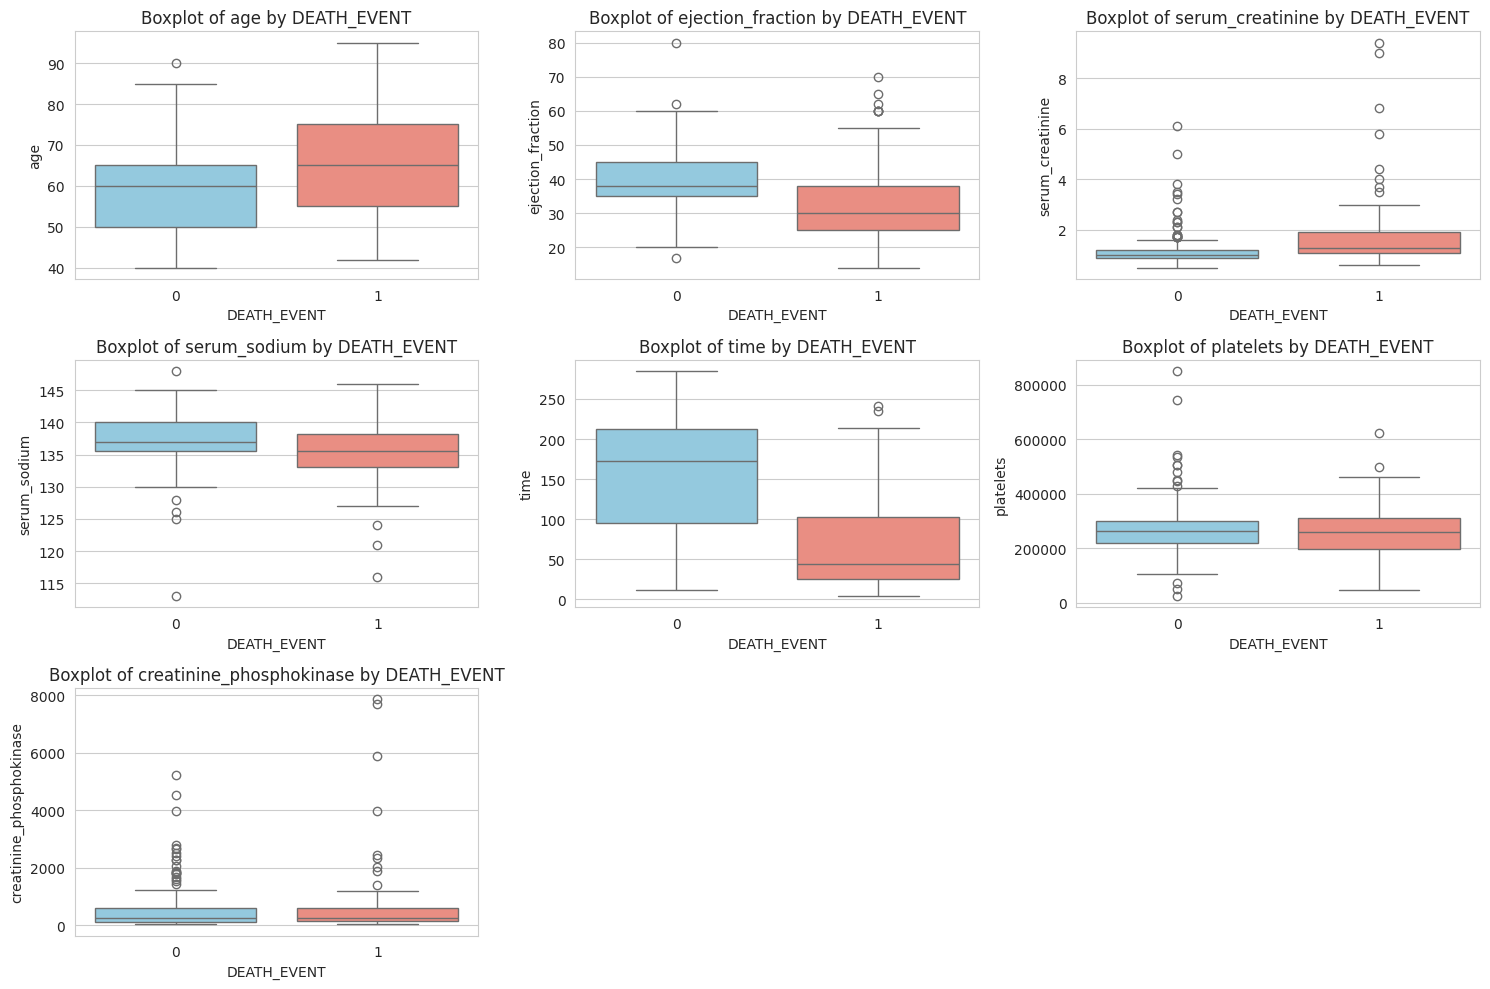

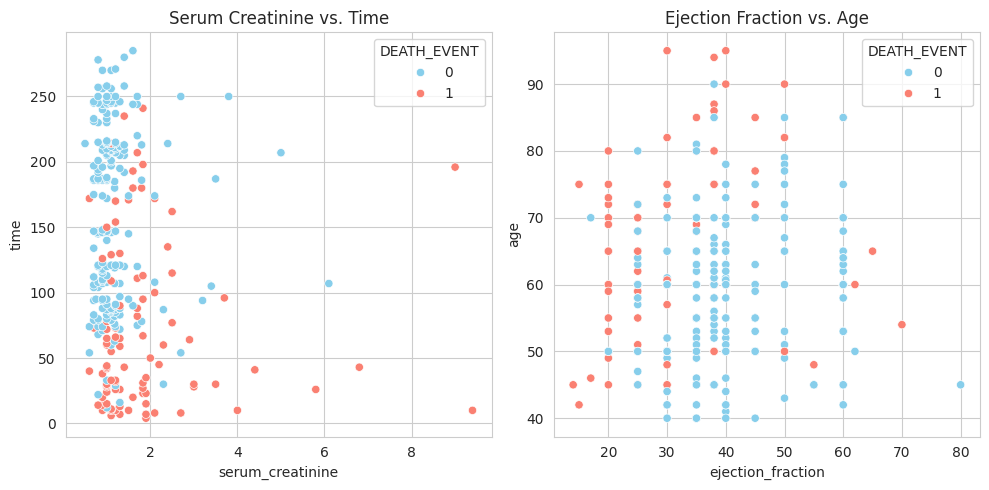

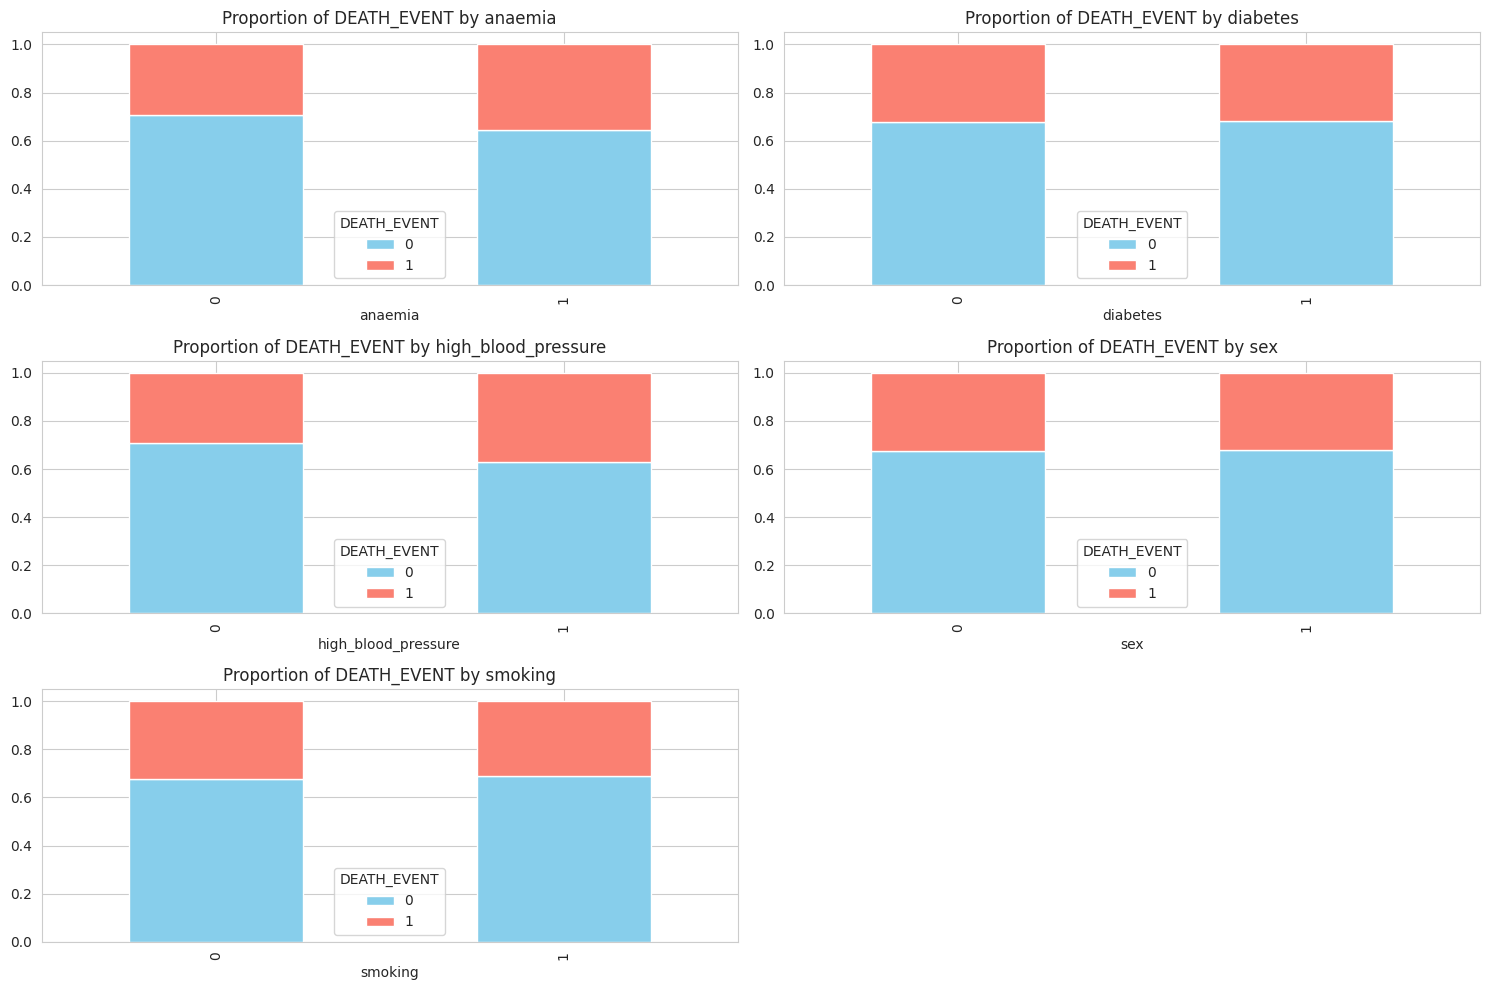

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Define numerical and categorical features
numerical_features = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time', 'platelets', 'creatinine_phosphokinase']
categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

# Create histograms for numerical features, differentiated by DEATH_EVENT
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(x=feature, hue='DEATH_EVENT', data=df, kde=True, palette=['skyblue', 'salmon'])
    plt.title(f'Distribution of {feature} by DEATH_EVENT')
plt.tight_layout()
plt.show()


# Create box plots for numerical features, differentiated by DEATH_EVENT
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='DEATH_EVENT', y=feature, data=df, palette=['skyblue', 'salmon'])
    plt.title(f'Boxplot of {feature} by DEATH_EVENT')
plt.tight_layout()
plt.show()

# Create scatter plots for selected feature pairs
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='serum_creatinine', y='time', hue='DEATH_EVENT', data=df, palette=['skyblue', 'salmon'])
plt.title('Serum Creatinine vs. Time')
plt.subplot(1, 2, 2)
sns.scatterplot(x='ejection_fraction', y='age', hue='DEATH_EVENT', data=df, palette=['skyblue', 'salmon'])
plt.title('Ejection Fraction vs. Age')
plt.tight_layout()
plt.show()


# Create bar charts for categorical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 2, i + 1)
    df.groupby(feature)['DEATH_EVENT'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, ax=plt.gca(), color=['skyblue', 'salmon'])
    plt.title(f'Proportion of DEATH_EVENT by {feature}')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures # Import PolynomialFeatures
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, precision_score, recall_score, f1_score

# Load dataset
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv
!ls -l

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Handle missing values
df.fillna(df.mean(), inplace=True)

# Select only the relevant features: Ejection Fraction and Serum Creatinine
X = df[['ejection_fraction', 'serum_creatinine']]  # Only these two columns
y = df['DEATH_EVENT']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# -----------------------------------------------------------
# Classification Models (5 Models)
# -----------------------------------------------------------

# 1. Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# 2. Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

# 3. Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

# 4. Support Vector Classifier (SVC)
svc_classifier = SVC()
svc_classifier.fit(X_train, y_train)
y_pred_svc = svc_classifier.predict(X_test)

# 5. K-Nearest Neighbors Classifier (KNN)
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
y_pred_knn = knn_classifier.predict(X_test)

# Evaluate Classification Models (Accuracy, Precision, Recall, F1-Score)
print("\nClassification Models Evaluation:")

# Logistic Regression
print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg)}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg)}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg)}")
print(f"F1 Score: {f1_score(y_test, y_pred_log_reg)}")

# Decision Tree Classifier
print("\nDecision Tree Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print(f"Precision: {precision_score(y_test, y_pred_dt)}")
print(f"Recall: {recall_score(y_test, y_pred_dt)}")
print(f"F1 Score: {f1_score(y_test, y_pred_dt)}")

# Random Forest Classifier
print("\nRandom Forest Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf)}")

# Support Vector Classifier
print("\nSupport Vector Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc)}")
print(f"Precision: {precision_score(y_test, y_pred_svc)}")
print(f"Recall: {recall_score(y_test, y_pred_svc)}")
print(f"F1 Score: {f1_score(y_test, y_pred_svc)}")

# K-Nearest Neighbors Classifier
print("\nK-Nearest Neighbors Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)}")
print(f"Precision: {precision_score(y_test, y_pred_knn)}")
print(f"Recall: {recall_score(y_test, y_pred_knn)}")
print(f"F1 Score: {f1_score(y_test, y_pred_knn)}")


# -----------------------------------------------------------
# Regression Models (5 Models)
# -----------------------------------------------------------

# 1. Linear Regression
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
y_pred_lr = linear_regressor.predict(X_test)

# 2. Ridge Regression
ridge_regressor = Ridge(alpha=1.0)
ridge_regressor.fit(X_train, y_train)
y_pred_ridge = ridge_regressor.predict(X_test)

# 3. Lasso Regression
lasso_regressor = Lasso(alpha=0.1)
lasso_regressor.fit(X_train, y_train)
y_pred_lasso = lasso_regressor.predict(X_test)

# 4. Polynomial Regression
polynomial_features = PolynomialFeatures(degree=3)
X_train_poly = polynomial_features.fit_transform(X_train)
X_test_poly = polynomial_features.transform(X_test)

poly_regressor = LinearRegression()
poly_regressor.fit(X_train_poly, y_train)
y_pred_poly = poly_regressor.predict(X_test_poly)

# 5. Support Vector Regression (SVR)
svr_regressor = SVR(kernel='rbf')
svr_regressor.fit(X_train, y_train)
y_pred_svr = svr_regressor.predict(X_test)

# Evaluate Regression Models (MSE, R2 Score)
print("\nRegression Models Evaluation:")

# Linear Regression
print("\nLinear Regression:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lr)}")
print(f"R2 Score: {r2_score(y_test, y_pred_lr)}")

# Ridge Regression
print("\nRidge Regression:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_ridge)}")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge)}")

# Lasso Regression
print("\nLasso Regression:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lasso)}")
print(f"R2 Score: {r2_score(y_test, y_pred_lasso)}")

# Polynomial Regression
print("\nPolynomial Regression:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_poly)}")
print(f"R2 Score: {r2_score(y_test, y_pred_poly)}")

# Support Vector Regression
print("\nSupport Vector Regression:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_svr)}")
print(f"R2 Score: {r2_score(y_test, y_pred_svr)}")

--2025-04-08 14:51:39--  https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘heart_failure_clinical_records_dataset.csv.2’

heart_failure_clini     [ <=>                ]  11.95K  --.-KB/s    in 0s      

2025-04-08 14:51:40 (90.1 MB/s) - ‘heart_failure_clinical_records_dataset.csv.2’ saved [12239]

total 40
-rw-r--r-- 1 root root 12239 Apr  8 13:48 heart_failure_clinical_records_dataset.csv
-rw-r--r-- 1 root root 12239 Apr  8 13:50 heart_failure_clinical_records_dataset.csv.1
-rw-r--r-- 1 root root 12239 Apr  8 14:51 heart_failure_clinical_records_dataset.csv.2
drwxr-xr-x 1 root root  4096 Apr  4 13:38 sample_data

Classification Models Evaluation:

Logistic Regression:
Accuracy: 0.63333333333333